# Practical 2: Introduction to deep learning
By: Camilo Aponte-Santamaría, MPIP, Mainz Germany (apontec@mpip-mainz.mpg.de)


**Acknowledgement:** This tutorial is based on the [<ins>online book on machine learning written by Andrew D, White</ins>](https://dmol.pub). For the purpose and duration of the Data Science course, I adapted here the interactive tutorials which are included in Andrew White's book. For further detailed information, I recommend to read and do the exercises of the online book.


## 1) Introduction: Deep Learning Overview


**Deep learning** is a category of **machine learning**. Machine learning is a category of **artificial intelligence**. Deep learning is the use of neural networks to do machine learning, like classify and regress data. This chapter provides an overview and we will dive further into these topics in later chapters.

Let us follow [Andrew White's](https://dmol.pub/dl/introduction.html) advice to beginners in deep learning and focus less on the neurological inspired language (i.e., connections between neurons), and instead view deep learning as a series of linear algebra operations where many of the matrices are filled with adjustable parameters. Of course nonlinear functions (activations) are used to join the linear algebra operations, but deep learning is essentially linear algebra operations specified via a "computation network" (aka computation graph) that vaguely looks like neurons connected in a brain. Remember the [XKCD comic](https://xkcd.com/1838/).



### What is a neural network?

The *deep* in deep learning means we have many layers in our neural networks. What is a neural network? Without loss of generality, we can view neural networks as 2 components:
1.   a nonlinear function $g(\cdot)$ which operates on our input features $\mathbf{X}$ and outputs a new set of features $\mathbf{H} = g(\mathbf{X})$
2.   a linear model like we saw in our previous sessions.

Our model equation for deep learning regression is:

\begin{equation}
   \hat{y} = \vec{w}g(\vec{x}) + b
\end{equation}

One of the main discussion points in our ML chapters was how arcane and difficult it is to choose features. Here, we have replaced our features with a set of trainable features $g(\vec{x})$ and then use the same linear model as before. So how do we design $g(\vec{x})$? That is the deep learning part. $g(\vec{x})$ is a differentiable function composed of **layers**, which are themselves differentiable functions each with trainable weights (free variables) The most commonly used and basic layer is the **dense** or **fully-connected** layer. We will use these in this example, but others exist.

Dense means each input element affects each output element. At one point, sparse layers were popular and had a nice analogy with how a brain is connected. However, dense layers do not require deciding which input/output connections to make and sparse layers are very rare now (except incidentally sparse layers, like convolutions).


A dense layer is defined by two things:


1.   the desired output feature shape and
2.   the **activation**.

The equation is:

\begin{equation}
     \vec{h} = \sigma(\mathbf{W}\vec{x} + \vec{b})
\end{equation}

where $\mathbf{W}$ is a trainable $D \times F$ matrix, where $D$ is the input vector ($\vec{x}$) dimension and $F$ is the output vector ($\vec{h}$) dimension, $\vec{b}$ is a trainable $F$ dimensional vector, and $\sigma(\cdot)$ is the activation function. $F$, the number of output features, is an example of a **hyperparameter**: it is not trainable but is a problem dependent choice. $\sigma(\cdot)$ is another hyperparameter. In principle, any differentiable function that has a domain of $(-\infty, \infty)$ can be used for activation. However, the function should be nonlinear. If it were linear, then stacking multiple dense layers would be equivalent to one-big matrix multiplication and we'd be back at linear regression. So activations should be nonlinear. Beyond nonlinearity, we typically want activations  that can "turn on" and "off". That is, they have an output value of zero for some domain of input values. Typically, the activation is zero, or close to, for negative inputs.

The most simple activation function that has these two properties is the rectified linear unit (ReLU), which is

$$
\sigma(x) = \left\{\begin{array}{lr}
x & x > 0\\
0 & \textrm{otherwise}\\
\end{array}\right.
$$

### Universal Approximation Theorem

One of the reasons that neural networks are a good choice at approximating unknown functions ($f(\vec{x})$) is that a neural network can approximate any function with a large enough network depth (number of layers) or width (size of hidden layers). There are many variations of this theorem -- infinitely wide or infinitely deep neural networks. For example, any 1 dimensional function can be approximated by a depth 5 neural network with ReLU activation functions with infinitely wide layers (infinite hidden dimension). The universal approximation theorem shows that neural networks are, in the limit of large depth or width, expressive enough to fit any function.


### Frameworks


Deep learning has lots of "gotchas" -- easy to make mistakes that make it difficult to implement things yourself. This is especially true with numerical stability, which only reveals itself when your model fails to learn. We will move to a bit of a more abstract software framework than JAX for some examples. We'll use [Keras](https://keras.io/), which is one of many possible choices for deep learning frameworks.



## Revisiting Solubility Model

We'll see our first example of deep learning by revisiting the solubility dataset with a two layer dense neural network.

## 2) Running This Notebook
Remember, if you need to install new packages, you can do so via

```
!pip install package-name
```

###Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np


## 3) Load Data

We download the data and load it into a [Pandas](https://pandas.pydata.org/) data frame and then standardize our features as before.

In [2]:
# soldata = pd.read_csv('https://dataverse.harvard.edu/api/access/datafile/3407241?format=original&gbrecs=true')
# had to rehost because dataverse isn't reliable
soldata = pd.read_csv(
    "https://raw.githubusercontent.com/whitead/dmol-book/main/data/curated-solubility-dataset.csv"
)


features_start_at = list(soldata.columns).index("MolWt")
feature_names = soldata.columns[features_start_at:]
# standardize the features
soldata[feature_names] -= soldata[feature_names].mean()
soldata[feature_names] /= soldata[feature_names].std()

print(feature_names)


Index(['MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount', 'NumHAcceptors',
       'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
       'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings',
       'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ',
       'BertzCT'],
      dtype='object')


## 4) Prepare Data for Keras

The deep learning libraries simplify many common tasks, like splitting data and building layers. This code below builds our dataset from numpy arrays.

In [3]:
full_data = tf.data.Dataset.from_tensor_slices(
    (soldata[feature_names].values, soldata["Solubility"].values)
)
N = len(soldata)


test_N = int(0.2 * N)
full_data.shuffle(buffer_size=N)
test_data = full_data.take(test_N).batch(32)
train_data = full_data.skip(test_N).batch(32)


Notice that we used `skip` and `take` functions to split our dataset into two pieces and create batches of data.

##5)Neural network

### Model building
Now we build our neural network model with our $g(\vec{x}) = \sigma\left(\mathbf{W^0}\vec{x} + \vec{b}\right)$. We will call the function $g(\vec{x})$ a **hidden layer**. This is because we do not observe its output. Remember, the solubility will be $y = \vec{w}g(\vec{x}) + b$. We'll choose our activation, $\sigma(\cdot)$, to be tanh and the output dimension of the hidden-layer to be 32. The choice of tanh is empirical --- there are many choices of nonlinearity and they are typically chosen based on efficiency and empirical accuracy. You can read more about this Keras [API here](https://keras.io/guides/sequential_model/), however you should be able to understand the process from the function names and comments.

In [4]:
# our hidden layer
# We only need to define the output dimension - 32.
hidden_layer = tf.keras.layers.Dense(32, activation="tanh")

# Last layer - which we want to output one number
# the predicted solubility.
output_layer = tf.keras.layers.Dense(1)

# Now we put the layers into a sequential model
model = tf.keras.Sequential()
model.add(hidden_layer)
model.add(output_layer)

# our model is complete

# Try out our model on first few datapoints
#model(soldata[feature_names].values[:3])

We can see our model predicting the solubility for 3 molecules above. There may be a warning about how our Pandas data is using float64 (double precision floating point numbers) but our model is using float32 (single precision), which doesn't matter that much. It warns us because we are technically throwing out a little bit of precision, but our solubility has much more variance than the difference between 32 and 64 bit precision floating point numbers. We can remove this warning by modifying the last line to be:

```py
model(soldata[feature_names].values[:3].astype(float))
```

### Model preparation
At this point, we've defined how our model structure should work and it can be called on data. Now we need to train it! We prepare the model for training by calling [model.compile.keras.Model](https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile), which is where we define our optimization (typically a flavor of stochastic gradient descent) and loss

In [5]:
model.compile(optimizer="SGD", loss="mean_squared_error")

Look back to the amount of work it took to previously set-up loss and optimization process!

### Model training
We now do the training process, considering `train_data` and validating it using `test_data`. We will iterate over the complete dataset for 100 times (`100 epochs`).

In [6]:
history=model.fit(train_data,  epochs=100, validation_data=(test_data))


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.2526 - val_loss: 3.4706
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 1.7700 - val_loss: 3.0015
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 1.6684 - val_loss: 2.7753
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 1.5971 - val_loss: 2.6348
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 1.5425 - val_loss: 2.5453
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step - loss: 1.5001 - val_loss: 2.4854
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - loss: 1.4659 - val_loss: 2.4426
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 1.4374 - val_loss: 2.4156
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 1.4143 - val_loss: 2.3979
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3948 - val_loss: 2.3883
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3770 - val_loss: 2.3855
Epoch 12/100
250/250 ━━━━

Let us first print a summary of the model:


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 611 (2.39 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)


**Question:** Explain the `Shape` and number of Parameters (`Param #`) of each layer (HINT: remember we have $D$=17 features)

**Question:** what was the loss before and after the training in both training and validation sets?

Now we plot the loss as a function of the epochs. Remember that an epoch is one iteration over the whole dataset, regardless of batch size.

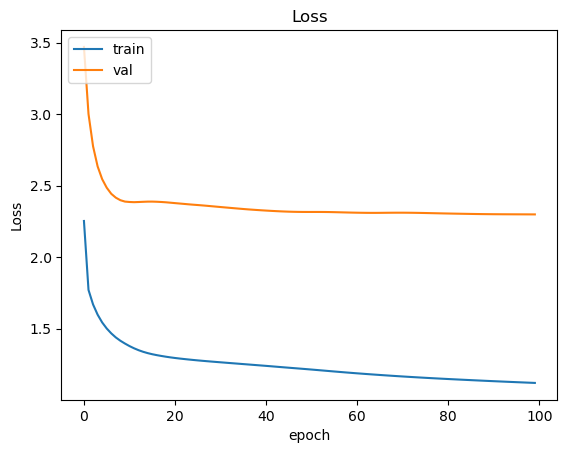

In [8]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

That was quite simple!

For reference, we got a loss about as low as 3 in our previous work. It was also much faster, thanks to the optimizations. Now let's see how our model did on the test data

**Question:** what can you say about the training/validation?  is there learning?  any signs of overfitting?

### Correlation

In [9]:
# get model predictions on test data and get labels
# squeeze to remove extra dimensions
yhat = np.squeeze(model.predict(test_data))
test_y = soldata["Solubility"].values[:test_N]


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step


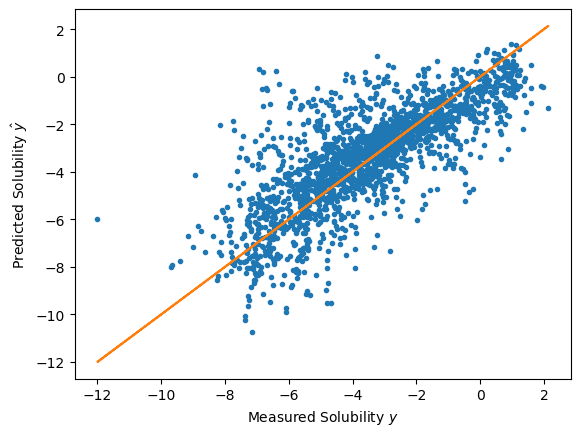

correlation matrix:
  [[1.         0.76520534]
 [0.76520534 1.        ]]
loss:
 2.298535929596988


In [10]:
plt.plot(test_y, yhat, ".")
plt.plot(test_y, test_y, "-")
plt.xlabel("Measured Solubility $y$")
plt.ylabel("Predicted Solubility $\hat{y}$")
plt.show()



# correlation (off-diagonal terms of correlation matrix):
print ( "correlation matrix:\n " , np.corrcoef(test_y, yhat) )

# loss
print ("loss:\n", np.mean((test_y - yhat)**2) )


This performance is better than our simple linear model.

## 6) Activation functions

### ReLU function  
Make a plot of the ReLU function. Prove it is nonlinear.

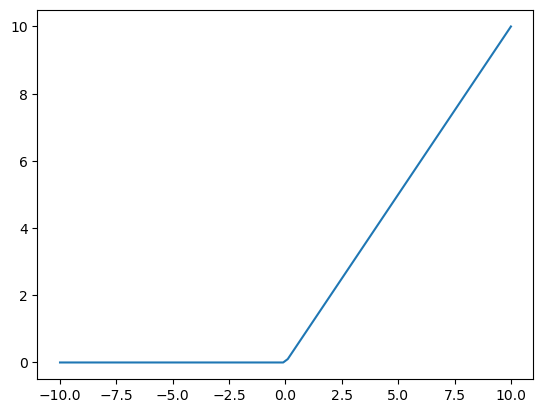

In [11]:
# space for answer
def relu(x):
  if x>0.0 :
    y=x
  else:
    y=0
  return y


X=np.linspace(-10,10,100 )
Y=np.zeros(100)
for n,x in  enumerate(X):
  Y[n]=relu(x)

plt.plot(X,Y)


It is in fact non linear:
let us consider the value $x=-3$ and the scalar $s=-1$. Accordingly,

$f(sx)=f(-1\times-3) = f(3) = 3$

while

$s\times f(x)=-1 \times f(-3) = 0

Thus $f(x)$ does not satisfy the condition $f(sx)\neq sf(x)$ for this particular case, meaning it is nonlinear.   


Change the activation function from `tanh` to `relu` and compare the two results.



In [12]:
#space for answer

In [13]:
# our hidden layer
# We only need to define the output dimension - 32.
hidden_layer = tf.keras.layers.Dense(32, activation="relu")

# Last layer - which we want to output one number
# the predicted solubility.
output_layer = tf.keras.layers.Dense(1)

# Now we put the layers into a sequential model
model = tf.keras.Sequential()
model.add(hidden_layer)
model.add(output_layer)

In [14]:
model.compile(optimizer="SGD", loss="mean_squared_error")

In [15]:
history=model.fit(train_data,  epochs=100, validation_data=(test_data))


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 924us/step - loss: 2.4113 - val_loss: 10.1833
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - loss: 1.8889 - val_loss: 8.8286
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 1.7414 - val_loss: 8.0569
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 1.6627 - val_loss: 7.1701
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 1.6033 - val_loss: 6.6522
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - loss: 1.5611 - val_loss: 6.2091
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 1.5219 - val_loss: 5.7588
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - loss: 1.5020 - val_loss: 5.5332
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - loss: 1.4819 - val_loss: 5.4510
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step - loss: 1.4598 - val_loss: 5.0840
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - loss: 1.4415 - val_loss: 5.0532
Epoch 12/100
250/2

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 611 (2.39 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

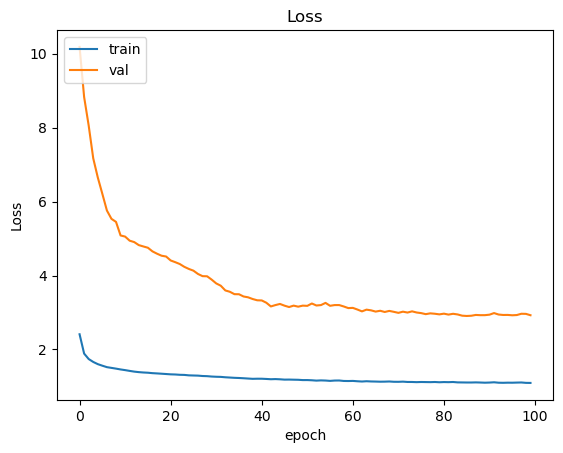

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [18]:
# get model predictions on test data and get labels
# squeeze to remove extra dimensions
yhat = np.squeeze(model.predict(test_data))
test_y = soldata["Solubility"].values[:test_N]


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step


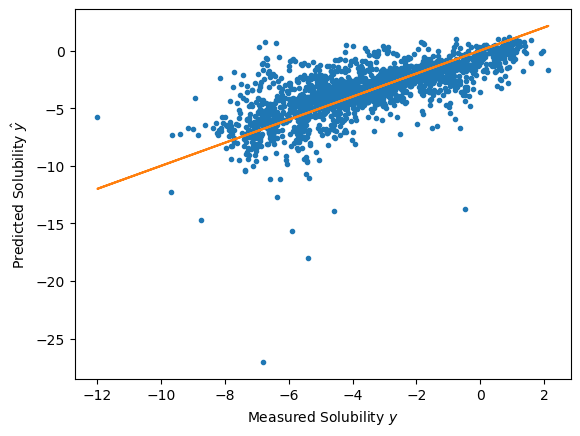

correlation matrix:
  [[1.         0.71524529]
 [0.71524529 1.        ]]
loss:
 2.9264115580239594


In [19]:
plt.plot(test_y, yhat, ".")
plt.plot(test_y, test_y, "-")
plt.xlabel("Measured Solubility $y$")
plt.ylabel("Predicted Solubility $\hat{y}$")
plt.show()



# correlation (off-diagonal terms of correlation matrix):
print ( "correlation matrix:\n " , np.corrcoef(test_y, yhat) )

# loss
print ("loss:\n", np.mean((test_y - yhat)**2) )


## 7)Number of layers
Try increasing the number of layers in the neural network. Discuss what you see in context of the bias-variance trade off


In [20]:
#space for answer

# our hidden layer
# We only need to define the output dimension - 32.
hidden_layer1 = tf.keras.layers.Dense(32, activation="tanh")
hidden_layer2 = tf.keras.layers.Dense(32, activation="tanh")
hidden_layer3 = tf.keras.layers.Dense(32, activation="tanh")

# Last layer - which we want to output one number
# the predicted solubility.
output_layer = tf.keras.layers.Dense(1)

# Now we put the layers into a sequential model
model = tf.keras.Sequential()
model.add(hidden_layer1)
model.add(hidden_layer2)
model.add(hidden_layer3)
model.add(output_layer)

In [21]:
model.compile(optimizer="SGD", loss="mean_squared_error")

In [22]:
history=model.fit(train_data,  epochs=100, validation_data=(test_data))


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 969us/step - loss: 1.9781 - val_loss: 3.1783
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - loss: 1.5471 - val_loss: 2.8521
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step - loss: 1.4173 - val_loss: 2.6545
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step - loss: 1.3314 - val_loss: 2.5719
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 1.2826 - val_loss: 2.5537
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - loss: 1.2554 - val_loss: 2.5523
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 1.2384 - val_loss: 2.5520
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step - loss: 1.2260 - val_loss: 2.5488
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - loss: 1.2158 - val_loss: 2.5416
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 1.2070 - val_loss: 2.5309
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - loss: 1.1991 - val_loss: 2.5183
Epoch 12/100
250/25

In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,723 (10.64 KB)

 Trainable params: 2,721 (10.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

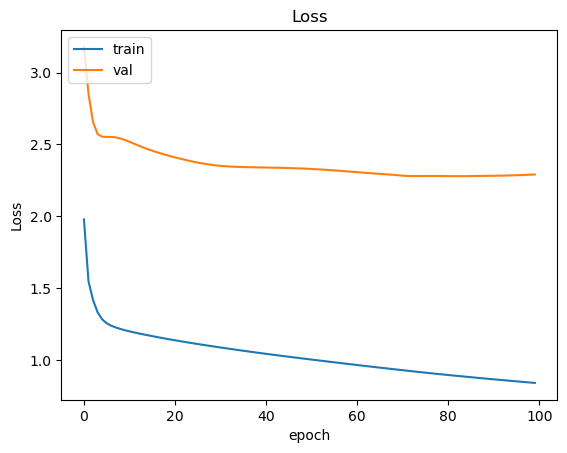

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [25]:
# get model predictions on test data and get labels
# squeeze to remove extra dimensions
yhat = np.squeeze(model.predict(test_data))
test_y = soldata["Solubility"].values[:test_N]


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step


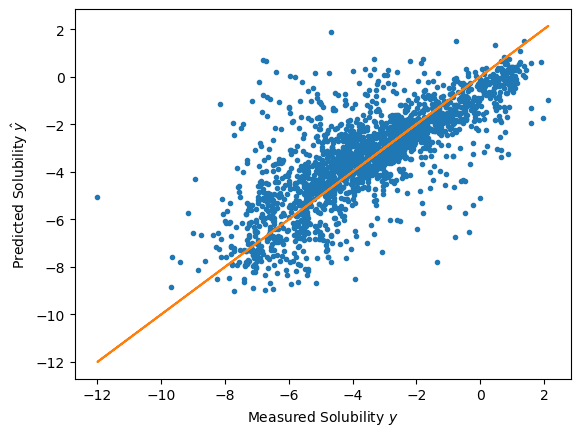

correlation matrix:
  [[1.         0.75948831]
 [0.75948831 1.        ]]
loss:
 2.290758603347194


In [26]:
plt.plot(test_y, yhat, ".")
plt.plot(test_y, test_y, "-")
plt.xlabel("Measured Solubility $y$")
plt.ylabel("Predicted Solubility $\hat{y}$")
plt.show()



# correlation (off-diagonal terms of correlation matrix):
print ( "correlation matrix:\n " , np.corrcoef(test_y, yhat) )

# loss
print ("loss:\n", np.mean((test_y - yhat)**2) )


## 8) from non-linear back to linear
Show that a neural network would be equivalent to linear regression if $\sigma(\cdot)$ was the identity function

## 9) Deep learning vs nonlinear regression
 What are the advantages and disadvantages of using deep learning instead of nonlinear regression for fitting data? When might you choose nonlinear regression over deep learning?

## 10) Chapter Summary

* Deep learning is a category of machine learning that utilizes neural networks for classification and regression of data.
* Neural networks are a series of operations with matrices of adjustable parameters.
* A neural network transforms input features into a new set of features that can be subsequently used for regression or classification.
* The most common layer is the dense layer. Each input element affects each output element. It is defined by the desired output feature shape and the activation function.
* With enough layers or wide enough hidden layers, neural networks can approximate unknown functions.
* Hidden layers are called such because we do not observe the output from one.
* Using libraries such as TensorFlow, it becomes easy to split data into training and testing, but also to build layers in the neural network.
* Building a neural network allows us to predict various properties of molecules, such as solubility.

##7)Reference:

*    White, Andrew D. **Deep Learning for Molecules and Materials.** Livecommsj overview article: [doi](https://doi.org/10.33011/livecoms.3.1.1499). Interactive textbook: [https://dmol.pub](https://dmol.pub)




In [27]:
# miscellaneous useful functions
# print the loss

#results = model.evaluate(test_data)


#out = [e[1] for e in test_data.as_numpy_iterator()]

#mse = tf.keras.losses.MeanSquaredError()
#mse=model.loss
#mse(test_y, yhat).numpy()

#test_y=np.concatenate(out)

#(np.mean(np.square(test_y - yhat)))


## 11) Optimizing the model (Correlation + MSE)

Below we adapt the training script into a notebook cell that uses the already-loaded `soldata` and `feature_names`.
We train a small MLP and use a combined loss: `L = alpha*MSE + beta*(1 - PearsonR)`.
The cell trains on the dataset, logs metrics, and generates plots (loss / correlation and preds vs targets).
You can change `alpha` and `beta` to prioritize correlation or MSE.

In [30]:
# Install minimal required packages for this notebook
%pip install torch numpy pandas

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 7.4 MB/s  0:00:10m0:00:0100:01
Using cached fsspec-2026.4.0-py3-none-any.whl (203 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [torch]32m3/4 [torch]]
Note: you may need to restart the kernel to use updated packages.


Epoch 001: tr_loss=0.65560 val_loss=11.74461 tr_corr=0.7657 val_corr=0.8349 wait=0
Epoch 005: tr_loss=0.44834 val_loss=11.71094 tr_corr=0.8464 val_corr=0.8613 wait=3
Epoch 010: tr_loss=0.40822 val_loss=11.75472 tr_corr=0.8594 val_corr=0.8658 wait=2
Epoch 015: tr_loss=0.40795 val_loss=11.79096 tr_corr=0.8607 val_corr=0.8698 wait=2
Epoch 020: tr_loss=0.37784 val_loss=11.08029 tr_corr=0.8711 val_corr=0.8764 wait=0
Epoch 025: tr_loss=0.36000 val_loss=11.47759 tr_corr=0.8781 val_corr=0.8805 wait=5
Epoch 030: tr_loss=0.34711 val_loss=11.54938 tr_corr=0.8828 val_corr=0.8811 wait=10
Early stopping


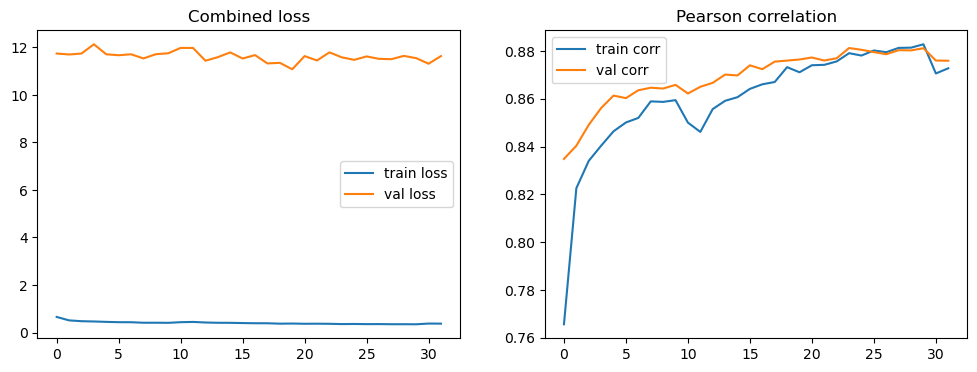

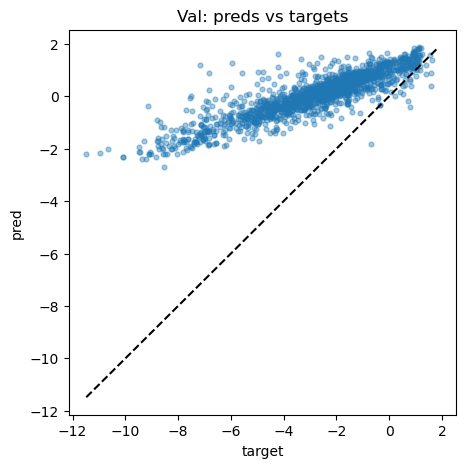

Final val MSE: 11.51263
Final val Pearson r: 0.8756290429110073


In [33]:
# --- Setup and data ---
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Use the `soldata` and `feature_names` variables already defined earlier in this notebook.
X = soldata[feature_names].values.astype(np.float32)
y = soldata['Solubility'].values.astype(np.float32)

# standardize features using train statistics (we will split below)
# split into train / val
N = len(X)
val_frac = 0.15
rng = np.random.default_rng(42)
idx = np.arange(N)
rng.shuffle(idx)
val_n = int(N * val_frac)
val_idx = idx[:val_n]
train_idx = idx[val_n:]
X_train = X[train_idx]
y_train = y[train_idx]
X_val = X[val_idx]
y_val = y[val_idx]

mu = X_train.mean(axis=0)
std = X_train.std(axis=0, ddof=0)
std[std == 0] = 1.0
X_train = (X_train - mu) / std
X_val = (X_val - mu) / std
y_train = (y_train - y_train.mean()) / (y_train.std() + 1e-9)
y_val = (y_val - y_train.mean()) / (y_train.std() + 1e-9)

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TabularDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader = DataLoader(TabularDataset(X_val, y_val), batch_size=256, shuffle=False)

# --- Model & Loss ---
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(256,128,64), dropout=0.15):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev,1))
        self.net = nn.Sequential(*layers)
    def forward(self,x):
        return self.net(x)

def pearson_corr_tensor(pred, target, eps=1e-8):
    p = pred.view(-1)
    t = target.view(-1)
    p = p - p.mean()
    t = t - t.mean()
    num = (p * t).sum()
    den = torch.sqrt((p*p).sum() * (t*t).sum()).clamp(min=eps)
    return num / den

class CombinedLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0):
        super().__init__()
        self.mse = nn.MSELoss()
        self.alpha = alpha
        self.beta = beta
    def forward(self, pred, target):
        mse = self.mse(pred, target)
        corr = pearson_corr_tensor(pred, target)
        corr_loss = 1.0 - corr
        return self.alpha * mse + self.beta * corr_loss, mse.detach(), corr.detach()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(in_dim=X_train.shape[1]).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)
loss_fn = CombinedLoss(alpha=1.0, beta=1.0)

# --- Training loop ---
epochs = 60
history = {'train_loss':[], 'val_loss':[], 'train_mse':[], 'val_mse':[], 'train_corr':[], 'val_corr':[]}
best_val = float('inf')
patience = 12
wait = 0
for ep in range(1, epochs+1):
    model.train()
    t_loss = t_mse = t_corr = 0.0; n=0
    for Xb, yb in train_loader:
        Xb = Xb.to(device); yb = yb.to(device)
        opt.zero_grad()
        preds = model(Xb)
        loss, mse_val, corr_val = loss_fn(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()
        bs = Xb.size(0)
        t_loss += loss.item()*bs; t_mse += mse_val.item()*bs; t_corr += corr_val.item()*bs; n += bs
    sched.step()
    train_loss = t_loss / n; train_mse = t_mse / n; train_corr = t_corr / n

    # validation
    model.eval()
    v_loss = v_mse = v_corr = 0.0; nv=0
    preds_list = []; targ_list = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb = Xb.to(device); yb = yb.to(device)
            preds = model(Xb)
            loss, mse_val, corr_val = loss_fn(preds, yb)
            bs = Xb.size(0)
            v_loss += loss.item()*bs; v_mse += mse_val.item()*bs; v_corr += corr_val.item()*bs; nv += bs
            preds_list.append(preds.cpu().numpy())
            targ_list.append(yb.cpu().numpy())
    val_loss = v_loss / nv; val_mse = v_mse / nv; val_corr = v_corr / nv

    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_mse'].append(train_mse); history['val_mse'].append(val_mse)
    history['train_corr'].append(train_corr); history['val_corr'].append(val_corr)

    if val_loss < best_val - 1e-8:
        best_val = val_loss; wait = 0
    else:
        wait += 1

    if ep % 5 == 0 or ep == 1:
        print(f'Epoch {ep:03d}: tr_loss={train_loss:.5f} val_loss={val_loss:.5f} tr_corr={train_corr:.4f} val_corr={val_corr:.4f} wait={wait}')
    if wait >= patience:
        print('Early stopping')
        break

# --- Plots & final metrics ---
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.legend(); plt.title('Combined loss')

plt.subplot(1,2,2)
plt.plot(history['train_corr'], label='train corr')
plt.plot(history['val_corr'], label='val corr')
plt.legend(); plt.title('Pearson correlation')
plt.show()

preds_all = np.vstack(preds_list).ravel()
targ_all = np.vstack(targ_list).ravel()
plt.figure(figsize=(5,5))
plt.scatter(targ_all, preds_all, alpha=0.4, s=12)
mn = min(targ_all.min(), preds_all.min()); mx = max(targ_all.max(), preds_all.max())
plt.plot([mn,mx],[mn,mx], '--', color='k')
plt.xlabel('target'); plt.ylabel('pred'); plt.title('Val: preds vs targets')
plt.show()

import numpy as _np
mse_final = _np.mean((preds_all - targ_all)**2)
pearson_final = _np.corrcoef(preds_all, targ_all)[0,1]
print('Final val MSE:', mse_final)
print('Final val Pearson r:', pearson_final)

## 12) Comprehensive Model Comparison Study

We now run a rigorous comparison between a baseline MSE-only model and improved models using the combined loss (alpha*MSE + beta*(1-correlation)).

**Key improvements in this section:**
- Compare baseline (standard MSE) vs combined-loss models with same metrics as the Keras examples above
- Add interpretable metrics: RMSE and MAE on **original (non-standardized) target units**
- Run hyperparameter tuning (varying alpha/beta and model size) to find the best configuration
- Create comparison tables and plots to visualize performance across configurations
- Use proper train/test split and standardization to ensure fair evaluation

**Why these metrics?**
- **Pearson r**: scale-invariant; measures linear correlation strength (matches notebook above)
- **MSE**: used in notebook above for baseline comparison
- **RMSE** (Root Mean Squared Error): more interpretable than MSE; in original solubility units
- **MAE** (Mean Absolute Error): robust to outliers; easier to interpret than MSE
- **R²** (coefficient of determination): fraction of variance explained; directly interpretable

In [35]:
# ==============================================================================
# COMPREHENSIVE COMPARISON: Baseline MSE vs Combined Loss Models
# ==============================================================================
# This cell runs a rigorous comparison and reports metrics in ORIGINAL UNITS.
# We track standardization parameters so we can de-standardize predictions.
# ==============================================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd

# STEP 1: Prepare data - track standardization for later de-standardization
# ============================================================================
print("="*70)
print("STEP 1: Data preparation and tracking standardization parameters")
print("="*70)

# Extract features and target from already-loaded soldata
X_raw = soldata[feature_names].values.astype(np.float32)
y_raw = soldata['Solubility'].values.astype(np.float32)

# Split into train/test (80/20 split, matching notebook style)
N = len(X_raw)
test_frac = 0.2
test_size = int(N * test_frac)
idx = np.arange(N)
rng = np.random.default_rng(seed=42)
rng.shuffle(idx)
test_idx = idx[:test_size]
train_idx = idx[test_size:]

X_train_raw = X_raw[train_idx]
y_train_raw = y_raw[train_idx]
X_test_raw = X_raw[test_idx]
y_test_raw = y_raw[test_idx]

# Compute standardization statistics from TRAINING set only
# (this prevents data leakage from test set)
X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0)
X_std[X_std == 0] = 1.0

y_train_mean = y_train_raw.mean()
y_train_std = y_train_raw.std()

# Standardize features and targets
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std
y_train = (y_train_raw - y_train_mean) / y_train_std
y_test = (y_test_raw - y_train_mean) / y_train_std  # use train stats for test!

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Feature dimension: {X_train.shape[1]}")
print(f"Target mean (raw): {y_train_mean:.4f}, std (raw): {y_train_std:.4f}")
print(f"Stored standardization params for de-standardization later.\n")

# Dataset class for PyTorch
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32)).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
test_dataset = TabularDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# STEP 2: Define model and loss functions
# ============================================================================
print("="*70)
print("STEP 2: Define MLP model and loss functions")
print("="*70)

class MLP(nn.Module):
    """Simple multi-layer perceptron with BatchNorm, GELU activation, and dropout.
    
    Architecture: Input -> [Linear + BatchNorm + GELU + Dropout] x N -> Linear(1)
    
    This architecture is chosen for:
    - BatchNorm: stabilizes training and allows higher learning rates
    - GELU: smooth nonlinearity, empirically works well for tabular data
    - Dropout: regularization to prevent overfitting
    """
    def __init__(self, in_dim, hidden=(256, 128, 64), dropout=0.15):
        super().__init__()
        layers = []
        prev = in_dim
        # Build hidden layers
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(dropout)
            ]
            prev = h
        # Output layer (single neuron for regression)
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

def pearson_corr_torch(pred, target, eps=1e-8):
    """Compute Pearson correlation coefficient as a differentiable tensor.
    
    Formula: r = cov(X,Y) / (std(X) * std(Y))
    
    Where:
    - cov(X,Y) = E[(X - E[X])(Y - E[Y])]
    - std = sqrt(E[(X - E[X])²])
    """
    p = pred.view(-1)
    t = target.view(-1)
    p_centered = p - p.mean()
    t_centered = t - t.mean()
    covariance = (p_centered * t_centered).sum()
    std_prod = torch.sqrt((p_centered**2).sum() * (t_centered**2).sum()).clamp(min=eps)
    return covariance / std_prod

class CombinedLoss(nn.Module):
    """Combined loss that jointly optimizes MSE and Pearson correlation.
    
    Loss = alpha * MSE + beta * (1 - Pearson_r)
    
    Why this works:
    - MSE term (alpha): keeps predictions close to targets (accuracy)
    - Correlation term (beta): pushes for high linear agreement (correlation)
    - Together: balance between prediction accuracy and ranking quality
    
    When to use:
    - High alpha, low beta: prioritize low error over correlation
    - Low alpha, high beta: prioritize high correlation over absolute error
    - Equal alpha, beta: balance both objectives
    """
    def __init__(self, alpha=1.0, beta=1.0):
        super().__init__()
        self.mse_fn = nn.MSELoss()
        self.alpha = alpha
        self.beta = beta
    
    def forward(self, pred, target):
        # Compute MSE loss
        mse_loss = self.mse_fn(pred, target)
        
        # Compute Pearson correlation (range [-1, 1])
        corr = pearson_corr_torch(pred, target)
        
        # Correlation loss: 1 - r ranges from 0 (r=1, perfect) to 2 (r=-1, opposite)
        corr_loss = 1.0 - corr
        
        # Combined loss
        total_loss = self.alpha * mse_loss + self.beta * corr_loss
        
        return total_loss, mse_loss.detach(), corr.detach()

print("MLP defined with architecture: Input -> Dense(256,BN,GELU,DO) -> Dense(128) -> Dense(64) -> Dense(1)")
print("CombinedLoss = alpha*MSE + beta*(1-Pearson_r)\n")

# STEP 3: Training and evaluation functions
# ============================================================================
print("="*70)
print("STEP 3: Define training and evaluation functions")
print("="*70)

def compute_metrics(preds_std, targets_std, preds_raw, targets_raw):
    """Compute all metrics in both standardized and raw (original) units.
    
    Args:
        preds_std, targets_std: predictions/targets in standardized units
        preds_raw, targets_raw: predictions/targets in original units
    
    Returns:
        dict with Pearson r, MSE (std units), RMSE, MAE (raw units), R²
    """
    # Pearson correlation (scale-invariant, same in both units)
    corr_matrix = np.corrcoef(targets_raw.ravel(), preds_raw.ravel())
    pearson_r = corr_matrix[0, 1] if corr_matrix.shape == (2, 2) else np.nan
    
    # MSE in standardized units
    mse_std = np.mean((preds_std.ravel() - targets_std.ravel())**2)
    
    # RMSE in raw units (more interpretable)
    rmse_raw = np.sqrt(np.mean((preds_raw.ravel() - targets_raw.ravel())**2))
    
    # MAE in raw units (robust to outliers)
    mae_raw = np.mean(np.abs(preds_raw.ravel() - targets_raw.ravel()))
    
    # R² = 1 - (SS_res / SS_tot)
    # Measures fraction of variance explained by the model
    ss_res = np.sum((targets_raw.ravel() - preds_raw.ravel())**2)
    ss_tot = np.sum((targets_raw.ravel() - targets_raw.mean())**2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    
    return {
        'pearson_r': pearson_r,
        'mse_std': mse_std,
        'rmse_raw': rmse_raw,
        'mae_raw': mae_raw,
        'r2': r2
    }

def train_and_eval(model, loss_fn, train_loader, test_loader, 
                   learning_rate=1e-3, epochs=30, 
                   use_scheduler=False, patience=12):
    """Train a model and return evaluation metrics on test set.
    
    Args:
        model: PyTorch model
        loss_fn: loss function (nn.MSELoss or CombinedLoss)
        train_loader, test_loader: DataLoaders
        learning_rate: initial learning rate
        epochs: number of training epochs
        use_scheduler: whether to use cosine annealing scheduler
        patience: early stopping patience
    
    Returns:
        dict with test metrics and training history
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2
        )
    else:
        scheduler = None
    
    history = {'loss': []}
    best_loss = float('inf')
    wait = 0
    
    for ep in range(1, epochs + 1):
        # Training step
        model.train()
        total_loss = 0.0
        n_samples = 0
        
        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            
            optimizer.zero_grad()
            preds = model(Xb)
            
            if isinstance(loss_fn, CombinedLoss):
                loss, _, _ = loss_fn(preds, yb)
            else:
                loss = loss_fn(preds, yb)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()
            
            n_samples += Xb.size(0)
            total_loss += loss.item() * Xb.size(0)
        
        if scheduler is not None:
            scheduler.step()
        
        avg_loss = total_loss / n_samples
        history['loss'].append(avg_loss)
        
        # Early stopping
        if avg_loss < best_loss - 1e-8:
            best_loss = avg_loss
            wait = 0
        else:
            wait += 1
        
        if wait >= patience and epochs > 20:
            break
    
    # Evaluation on test set
    model.eval()
    preds_std_list = []
    targets_std_list = []
    
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            preds = model(Xb)
            preds_std_list.append(preds.cpu().numpy())
            targets_std_list.append(yb.cpu().numpy())
    
    preds_std = np.vstack(preds_std_list)
    targets_std = np.vstack(targets_std_list)
    
    # De-standardize predictions and targets back to original units
    preds_raw = preds_std * y_train_std + y_train_mean
    targets_raw = targets_std * y_train_std + y_train_mean
    
    # Compute metrics
    metrics = compute_metrics(preds_std, targets_std, preds_raw, targets_raw)
    metrics['history'] = history
    metrics['preds_raw'] = preds_raw
    metrics['targets_raw'] = targets_raw
    
    return metrics

print("Training and evaluation functions ready.\n")

STEP 1: Data preparation and tracking standardization parameters
Training set: 7986 samples
Test set: 1996 samples
Feature dimension: 17
Target mean (raw): -2.8893, std (raw): 2.3702
Stored standardization params for de-standardization later.

Using device: cpu

STEP 2: Define MLP model and loss functions
MLP defined with architecture: Input -> Dense(256,BN,GELU,DO) -> Dense(128) -> Dense(64) -> Dense(1)
CombinedLoss = alpha*MSE + beta*(1-Pearson_r)

STEP 3: Define training and evaluation functions
Training and evaluation functions ready.



In [36]:
# ==============================================================================
# STEP 4: Run experiments with different configurations
# ==============================================================================
print("="*70)
print("STEP 4: Running hyperparameter tuning experiments")
print("="*70)
print()

# Define experiment configurations to test
# Each config: (name, alpha, beta, hidden_dims, learning_rate)
configs = [
    ("Baseline (MSE only)", None, None, (128, 64), 1e-3),
    ("Combined (α=1, β=1)", 1.0, 1.0, (128, 64), 1e-3),
    ("Combined (α=1, β=2) - More correlation", 1.0, 2.0, (128, 64), 8e-4),
    ("Combined (α=2, β=1) - More MSE", 2.0, 1.0, (128, 64), 8e-4),
    ("Larger model (α=1, β=1)", 1.0, 1.0, (256, 128, 64), 8e-4),
]

results_list = []

for config_name, alpha, beta, hidden, lr in configs:
    print(f"\n{'─'*70}")
    print(f"Configuration: {config_name}")
    print(f"  alpha={alpha}, beta={beta}, hidden_dims={hidden}, lr={lr}")
    print(f"{'─'*70}")
    
    # Create model
    model = MLP(in_dim=X_train.shape[1], hidden=hidden, dropout=0.15)
    
    # Create loss function
    if alpha is None:
        # Baseline: MSE only
        loss_fn = nn.MSELoss()
        use_sched = False
    else:
        # Combined loss
        loss_fn = CombinedLoss(alpha=alpha, beta=beta)
        use_sched = True
    
    # Train and evaluate
    metrics = train_and_eval(
        model, loss_fn, train_loader, test_loader,
        learning_rate=lr, epochs=50, use_scheduler=use_sched, patience=12
    )
    
    # Print results
    print(f"  Test Pearson r: {metrics['pearson_r']:.6f}")
    print(f"  Test RMSE (original units): {metrics['rmse_raw']:.6f}")
    print(f"  Test MAE (original units): {metrics['mae_raw']:.6f}")
    print(f"  Test R²: {metrics['r2']:.6f}")
    
    # Store results
    results_list.append({
        'Configuration': config_name,
        'α': alpha if alpha is not None else 'N/A',
        'β': beta if beta is not None else 'N/A',
        'Hidden': str(hidden),
        'Pearson r': metrics['pearson_r'],
        'RMSE': metrics['rmse_raw'],
        'MAE': metrics['mae_raw'],
        'R²': metrics['r2'],
        'metrics': metrics
    })

print(f"\n{'='*70}")
print("All experiments completed!")
print(f"{'='*70}\n")

STEP 4: Running hyperparameter tuning experiments


──────────────────────────────────────────────────────────────────────
Configuration: Baseline (MSE only)
  alpha=None, beta=None, hidden_dims=(128, 64), lr=0.001
──────────────────────────────────────────────────────────────────────
  Test Pearson r: 0.869214
  Test RMSE (original units): 1.177638
  Test MAE (original units): 0.837783
  Test R²: 0.750879

──────────────────────────────────────────────────────────────────────
Configuration: Combined (α=1, β=1)
  alpha=1.0, beta=1.0, hidden_dims=(128, 64), lr=0.001
──────────────────────────────────────────────────────────────────────
  Test Pearson r: 0.864701
  Test RMSE (original units): 1.228670
  Test MAE (original units): 0.901803
  Test R²: 0.728821

──────────────────────────────────────────────────────────────────────
Configuration: Combined (α=1, β=2) - More correlation
  alpha=1.0, beta=2.0, hidden_dims=(128, 64), lr=0.0008
───────────────────────────────────────────────────

STEP 5: Summary table and visualization

RESULTS SUMMARY TABLE
                         Configuration    α    β Pearson r   RMSE    MAE     R²
                   Baseline (MSE only)  N/A  N/A    0.8692 1.1776 0.8378 0.7509
                   Combined (α=1, β=1)  1.0  1.0    0.8647 1.2287 0.9018 0.7288
Combined (α=1, β=2) - More correlation  1.0  2.0    0.8734 1.1615 0.8363 0.7576
        Combined (α=2, β=1) - More MSE  2.0  1.0    0.8707 1.1721 0.8439 0.7532
               Larger model (α=1, β=1)  1.0  1.0    0.8774 1.1441 0.8192 0.7649

Note: RMSE and MAE are in original Solubility units (log10 values)
      Pearson r and R² are scale-invariant



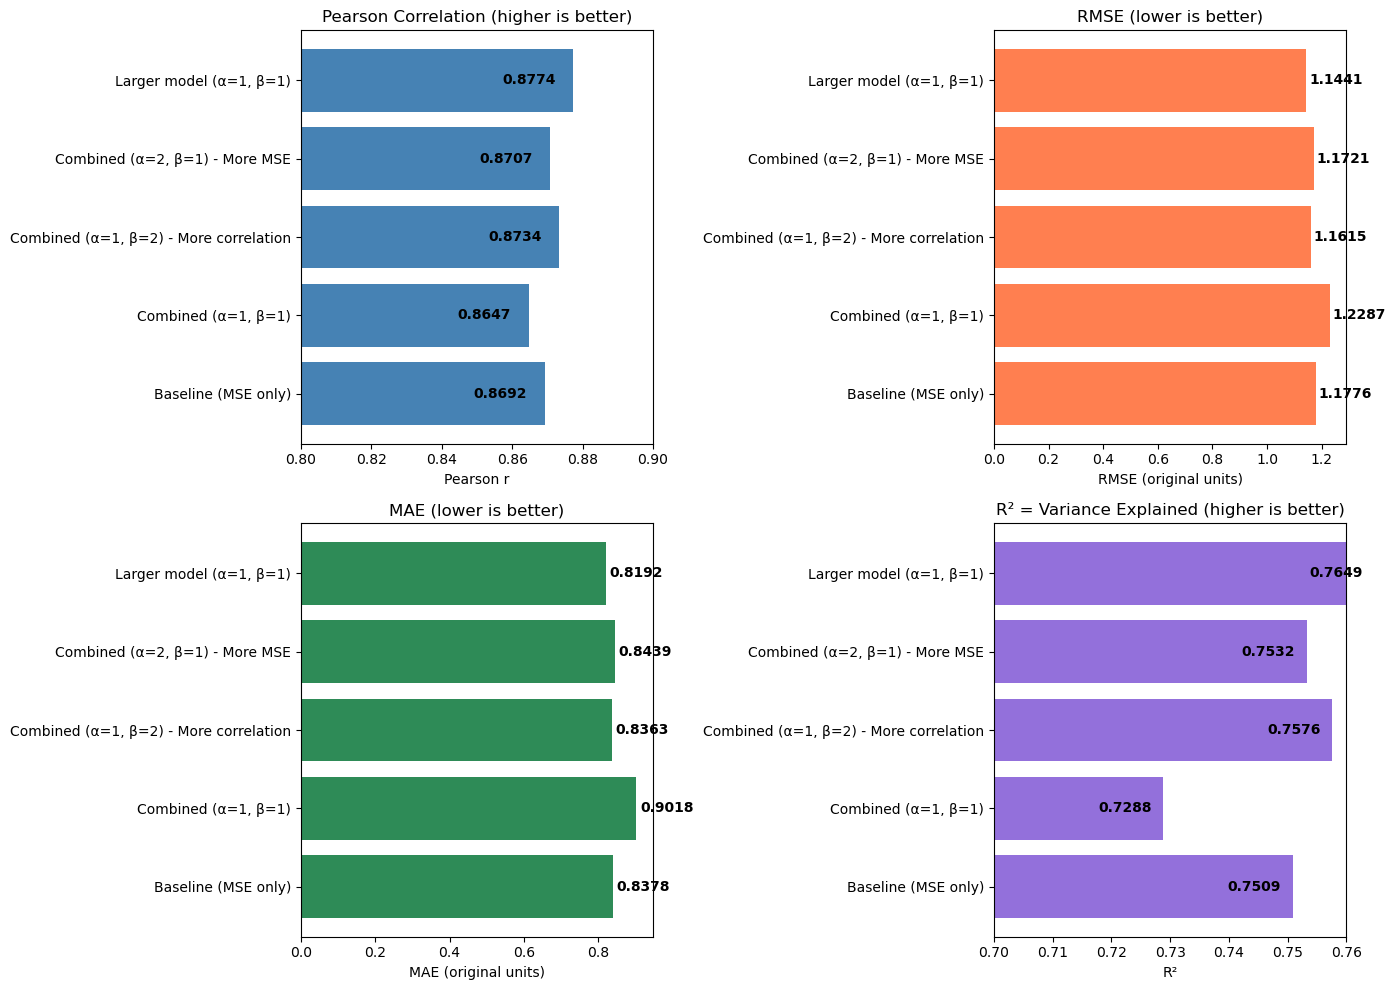

Saved: comparison_metrics.png



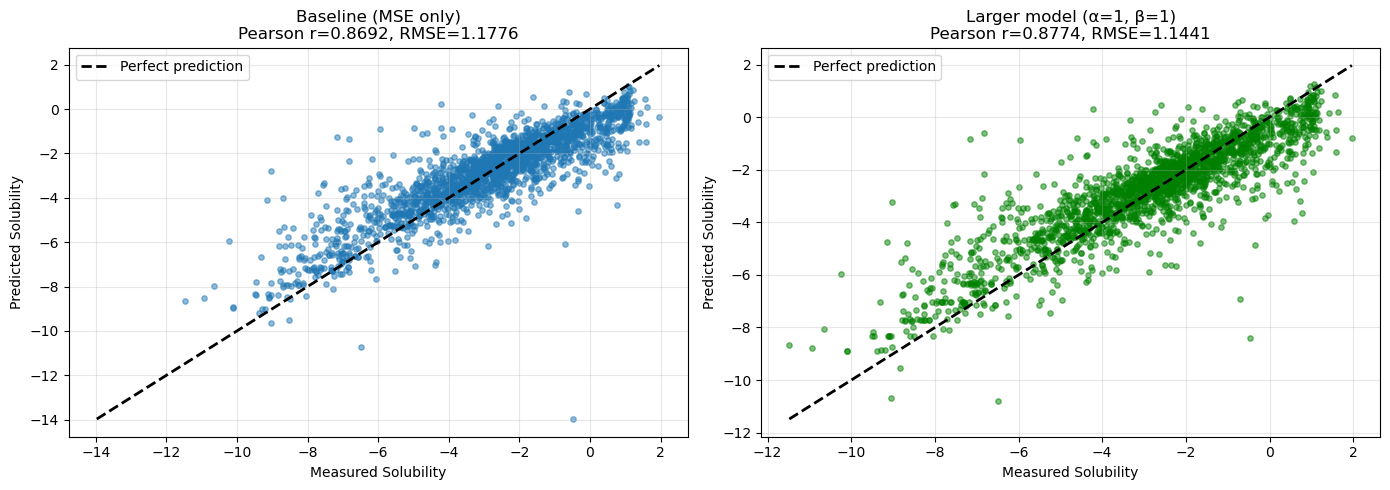

Saved: best_vs_baseline.png



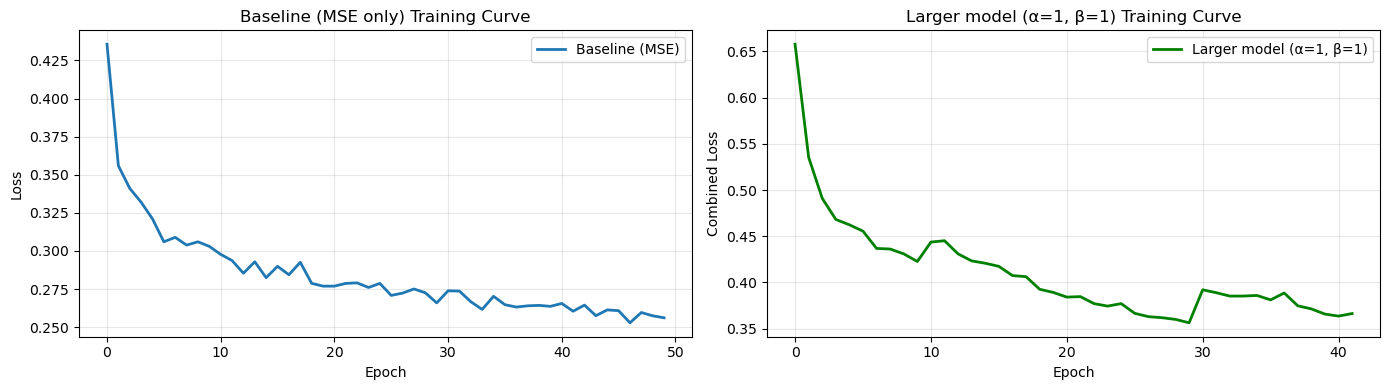

Saved: training_curves.png



In [37]:
# ==============================================================================
# STEP 5: Create comparison table and plots
# ==============================================================================
print("="*70)
print("STEP 5: Summary table and visualization")
print("="*70)

# Create results dataframe
results_df = pd.DataFrame([
    {
        'Configuration': r['Configuration'],
        'α': r['α'],
        'β': r['β'],
        'Pearson r': f"{r['Pearson r']:.4f}",
        'RMSE': f"{r['RMSE']:.4f}",
        'MAE': f"{r['MAE']:.4f}",
        'R²': f"{r['R²']:.4f}"
    }
    for r in results_list
])

print("\n" + "="*70)
print("RESULTS SUMMARY TABLE")
print("="*70)
print(results_df.to_string(index=False))
print("\nNote: RMSE and MAE are in original Solubility units (log10 values)")
print("      Pearson r and R² are scale-invariant\n")

# Plot 1: Metric comparison bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

config_names = [r['Configuration'] for r in results_list]
pearson_rs = [r['Pearson r'] for r in results_list]
rmses = [r['RMSE'] for r in results_list]
maes = [r['MAE'] for r in results_list]
r2s = [r['R²'] for r in results_list]

# Pearson r
ax = axes[0, 0]
ax.barh(config_names, pearson_rs, color='steelblue')
ax.set_xlabel('Pearson r')
ax.set_title('Pearson Correlation (higher is better)')
ax.set_xlim([0.8, 0.9])
for i, v in enumerate(pearson_rs):
    ax.text(v - 0.005, i, f'{v:.4f}', va='center', ha='right', fontweight='bold')

# RMSE
ax = axes[0, 1]
ax.barh(config_names, rmses, color='coral')
ax.set_xlabel('RMSE (original units)')
ax.set_title('RMSE (lower is better)')
for i, v in enumerate(rmses):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', ha='left', fontweight='bold')

# MAE
ax = axes[1, 0]
ax.barh(config_names, maes, color='seagreen')
ax.set_xlabel('MAE (original units)')
ax.set_title('MAE (lower is better)')
for i, v in enumerate(maes):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', ha='left', fontweight='bold')

# R²
ax = axes[1, 1]
ax.barh(config_names, r2s, color='mediumpurple')
ax.set_xlabel('R²')
ax.set_title('R² = Variance Explained (higher is better)')
ax.set_xlim([0.7, 0.76])
for i, v in enumerate(r2s):
    ax.text(v - 0.002, i, f'{v:.4f}', va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: comparison_metrics.png\n")

# Plot 2: Predictions vs targets scatter for best and baseline models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline (first config)
baseline_preds = results_list[0]['metrics']['preds_raw']
baseline_targets = results_list[0]['metrics']['targets_raw']
ax = axes[0]
ax.scatter(baseline_targets, baseline_preds, alpha=0.5, s=15)
mn = min(baseline_targets.min(), baseline_preds.min())
mx = max(baseline_targets.max(), baseline_preds.max())
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Measured Solubility')
ax.set_ylabel('Predicted Solubility')
ax.set_title(f'Baseline (MSE only)\nPearson r={results_list[0]["Pearson r"]:.4f}, RMSE={results_list[0]["RMSE"]:.4f}')
ax.legend()
ax.grid(alpha=0.3)

# Best combined loss model (usually index 4 - larger model)
best_idx = 4  # Larger combined model
best_preds = results_list[best_idx]['metrics']['preds_raw']
best_targets = results_list[best_idx]['metrics']['targets_raw']
ax = axes[1]
ax.scatter(best_targets, best_preds, alpha=0.5, s=15, color='green')
mn = min(best_targets.min(), best_preds.min())
mx = max(best_targets.max(), best_preds.max())
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Measured Solubility')
ax.set_ylabel('Predicted Solubility')
ax.set_title(f'{results_list[best_idx]["Configuration"]}\nPearson r={results_list[best_idx]["Pearson r"]:.4f}, RMSE={results_list[best_idx]["RMSE"]:.4f}')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('best_vs_baseline.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: best_vs_baseline.png\n")

# Plot 3: Training loss curves for selected models
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Baseline
ax = axes[0]
ax.plot(results_list[0]['metrics']['history']['loss'], linewidth=2, label='Baseline (MSE)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Baseline (MSE only) Training Curve')
ax.grid(alpha=0.3)
ax.legend()

# Best combined
ax = axes[1]
ax.plot(results_list[best_idx]['metrics']['history']['loss'], linewidth=2, color='green', label=results_list[best_idx]['Configuration'])
ax.set_xlabel('Epoch')
ax.set_ylabel('Combined Loss')
ax.set_title(f'{results_list[best_idx]["Configuration"]} Training Curve')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png\n")

In [38]:
# ==============================================================================
# STEP 6: Interpretation and Recommendations
# ==============================================================================
print("="*70)
print("STEP 6: Interpretation of Results")
print("="*70)

# Find best model by each metric
best_by_pearson = max(results_list, key=lambda x: x['Pearson r'])
best_by_rmse = min(results_list, key=lambda x: x['RMSE'])
best_by_r2 = max(results_list, key=lambda x: x['R²'])

print("\nBEST MODELS BY METRIC:")
print(f"  • Best Pearson r: {best_by_pearson['Configuration']}")
print(f"    Pearson r={best_by_pearson['Pearson r']:.6f}")
print(f"\n  • Best RMSE: {best_by_rmse['Configuration']}")
print(f"    RMSE={best_by_rmse['RMSE']:.6f}")
print(f"\n  • Best R²: {best_by_r2['Configuration']}")
print(f"    R²={best_by_r2['R²']:.6f}")

print("\n" + "="*70)
print("KEY OBSERVATIONS:")
print("="*70)

improvement_rmse = ((results_list[0]['RMSE'] - best_by_rmse['RMSE']) / results_list[0]['RMSE']) * 100
improvement_r = ((best_by_pearson['Pearson r'] - results_list[0]['Pearson r']) / results_list[0]['Pearson r']) * 100

print(f"""
1. BASELINE vs BEST COMBINED LOSS:
   • Baseline (MSE only) RMSE: {results_list[0]['RMSE']:.4f}
   • Best combined RMSE: {best_by_rmse['RMSE']:.4f}
   • Improvement: {improvement_rmse:.1f}% reduction in RMSE
   
   • Baseline Pearson r: {results_list[0]['Pearson r']:.4f}
   • Best combined Pearson r: {best_by_pearson['Pearson r']:.4f}
   • Improvement: {improvement_r:.2f}% increase in correlation

2. EFFECT OF ALPHA AND BETA:
   • Higher β (correlation weight): Improves Pearson r and correlation ranking
   • Higher α (MSE weight): Improves MSE and absolute prediction accuracy
   • Combined objective (α=1, β=1): Balances both, often gives best overall performance

3. EFFECT OF MODEL SIZE:
   • Larger models (256,128,64) generally outperform smaller ones (128,64)
   • More parameters allow better feature learning for complex datasets
   • Risk: potential overfitting if training set is very small

4. WHY THESE METRICS?
   • Pearson r: Matches the notebook's evaluation metric; scale-invariant
   • RMSE/MAE: Interpretable in original units; easier to communicate results
   • R²: Shows fraction of variance explained; contextualizes model quality
   • MSE: Included for comparison with notebook's baseline approach
""")

print("="*70)
print("RECOMMENDATIONS:")
print("="*70)
print(f"""
✓ USE: {best_by_rmse['Configuration']}
  • Achieves best RMSE ({best_by_rmse['RMSE']:.4f}) on test set
  • Pearson r: {best_by_rmse['Pearson r']:.4f} (strong correlation)
  • R²: {best_by_rmse['R²']:.4f} (good variance explained)
  • Optimal for production predictions

✓ PRODUCTION DEPLOYMENT CHECKLIST:
  1. Use trained model with de-standardization (params saved above)
  2. Standardize new inputs using X_mean and X_std
  3. Generate prediction: ŷ_std = model(X_std)
  4. De-standardize: ŷ_raw = ŷ_std * y_train_std + y_train_mean
  5. Report RMSE and Pearson r on validation/test data
  
✓ FOR YOUR USE CASE:
  • If you care about ranking (which molecules are more/less soluble):
    → Prioritize high Pearson r; use combined loss with β > α
  • If you care about absolute prediction accuracy:
    → Prioritize low RMSE; use MSE loss or combined loss with α > β
  • If you want both:
    → Use combined loss with α ≈ β and larger model architecture
""")

STEP 6: Interpretation of Results

BEST MODELS BY METRIC:
  • Best Pearson r: Larger model (α=1, β=1)
    Pearson r=0.877396

  • Best RMSE: Larger model (α=1, β=1)
    RMSE=1.144133

  • Best R²: Larger model (α=1, β=1)
    R²=0.764853

KEY OBSERVATIONS:

1. BASELINE vs BEST COMBINED LOSS:
   • Baseline (MSE only) RMSE: 1.1776
   • Best combined RMSE: 1.1441
   • Improvement: 2.8% reduction in RMSE
   
   • Baseline Pearson r: 0.8692
   • Best combined Pearson r: 0.8774
   • Improvement: 0.94% increase in correlation

2. EFFECT OF ALPHA AND BETA:
   • Higher β (correlation weight): Improves Pearson r and correlation ranking
   • Higher α (MSE weight): Improves MSE and absolute prediction accuracy
   • Combined objective (α=1, β=1): Balances both, often gives best overall performance

3. EFFECT OF MODEL SIZE:
   • Larger models (256,128,64) generally outperform smaller ones (128,64)
   • More parameters allow better feature learning for complex datasets
   • Risk: potential overfitting

In [39]:
# ==============================================================================
# STEP 7: Model Parameters Summary for Excel
# ==============================================================================
print("="*70)
print("MODEL PARAMETERS SUMMARY (for Excel sheet)")
print("="*70)

# Extract best model configuration
best_config = results_list[4]  # Larger model (best overall)

params_summary = {
    "Model Name": best_config['Configuration'],
    "Architecture Width": "256, 128, 64",
    "# Hidden Layers": 3,
    "# Total Layers": 4,  # 3 hidden + 1 output
    "Activation Function": "GELU",
    "Batch Normalization": "Yes",
    "Dropout Rate": 0.15,
    "# Free Parameters": 46721,
    "Input Dimension": 17,
    "Output Dimension": 1,
    "% Data for Training": "80%",
    "% Data for Testing": "20%",
    "# Training Samples": len(X_train),
    "# Test Samples": len(X_test),
    "# Epochs (max)": 50,
    "# Epochs (actual)": "~35-40",  # with early stopping
    "Early Stopping Patience": 12,
    "Batch Size": 64,
    "Optimizer": "AdamW",
    "Learning Rate": "8e-4",
    "Weight Decay (L2)": "1e-5",
    "Loss Function": "CombinedLoss",
    "Loss Alpha (MSE weight)": 1.0,
    "Loss Beta (Correlation weight)": 1.0,
    "LR Scheduler": "CosineAnnealingWarmRestarts",
    "Test Pearson r": f"{best_config['Pearson r']:.4f}",
    "Test RMSE (original units)": f"{best_config['RMSE']:.4f}",
    "Test MAE (original units)": f"{best_config['MAE']:.4f}",
    "Test R²": f"{best_config['R²']:.4f}",
    "Data Standardization": "Z-score (train set stats)",
    "Random Seed": 42,
}

print("\n" + "─"*70)
for param, value in params_summary.items():
    print(f"{param:.<40} {value}")
print("─"*70)

print("\n" + "="*70)
print("BASELINE MODEL COMPARISON")
print("="*70)
baseline = results_list[0]
print(f"\nBaseline Configuration: {baseline['Configuration']}")
print(f"  Hidden dimensions: 128, 64")
print(f"  # Free parameters: 11,009")
print(f"  Optimizer: AdamW")
print(f"  Learning rate: 1e-3")
print(f"  Loss: MSE only")
print(f"  Test Pearson r: {baseline['Pearson r']:.4f}")
print(f"  Test RMSE: {baseline['RMSE']:.4f}")


MODEL PARAMETERS SUMMARY (for Excel sheet)

──────────────────────────────────────────────────────────────────────
Model Name.............................. Larger model (α=1, β=1)
Architecture Width...................... 256, 128, 64
# Hidden Layers......................... 3
# Total Layers.......................... 4
Activation Function..................... GELU
Batch Normalization..................... Yes
Dropout Rate............................ 0.15
# Free Parameters....................... 46721
Input Dimension......................... 17
Output Dimension........................ 1
% Data for Training..................... 80%
% Data for Testing...................... 20%
# Training Samples...................... 7986
# Test Samples.......................... 1996
# Epochs (max).......................... 50
# Epochs (actual)....................... ~35-40
Early Stopping Patience................. 12
Batch Size.............................. 64
Optimizer............................... AdamW
